# Task 4 — Notebook 04: Spatial Prediction Maps and Discussion

**Goal:** Visualise predicted and true crop-type maps for the test year (2023), produce a difference (agreement/disagreement) map, and discuss model limitations and generalisability.

**Inputs:**
- Test predictions from `data/processed/task4/test_predictions_2023.parquet`
- Grid metadata derived from CDL parquet + NDVI metadata (via `load_grid_meta`)

**Outputs:**
- Predicted crop map, true crop map, and difference map (PNG + optional GeoTIFF)
- Discussion of model performance, limitations, and future work

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "task4_crop_mapping.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

FIGURES_DIR = REPO_ROOT / cfg["output"]["figures_dir"]
TABLES_DIR = REPO_ROOT / cfg["output"]["tables_dir"]
PROCESSED_DIR = REPO_ROOT / cfg["output"]["processed_dir"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["other_cropland", "corn", "soybean", "winter_wheat"]
CLASS_COLORS = ["#BFBFBF", "#FFD700", "#228B22", "#FF8C00"]

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling


## 1. Load Spatial Metadata and Predictions

In [2]:
from src.preprocessing.task4_panel import load_grid_meta

meta = load_grid_meta(REPO_ROOT)

HEIGHT = int(meta["height"])
WIDTH = int(meta["width"])
print(f"Grid: {HEIGHT} x {WIDTH}  |  CRS: {meta.get('crs', 'N/A')}")

pred_df = pd.read_parquet(PROCESSED_DIR / "test_predictions_2023.parquet")
print(f"Predictions: {len(pred_df):,} pixels")
print(f"Columns: {list(pred_df.columns)}")

Grid: 2960 x 4096  |  CRS: EPSG:5070
Predictions: 500,000 pixels
Columns: ['iy', 'ix', 'label', 'year', 'rotation_regime', 'predicted']


## 2. Reconstruct 2-D Rasters

In [3]:
from src.viz.prediction_maps import labels_to_raster

NODATA = -1

pred_raster = labels_to_raster(
    pred_df["iy"].values, pred_df["ix"].values,
    pred_df["predicted"].values,
    HEIGHT, WIDTH, nodata=NODATA,
)

true_raster = labels_to_raster(
    pred_df["iy"].values, pred_df["ix"].values,
    pred_df["label"].values,
    HEIGHT, WIDTH, nodata=NODATA,
)

print(f"Raster shape: {pred_raster.shape}")
print(f"Unique predicted: {np.unique(pred_raster)}")
print(f"Unique true:      {np.unique(true_raster)}")

Raster shape: (2960, 4096)
Unique predicted: [-1.  0.  1.  2.  3.]
Unique true:      [-1.  0.  1.  2.  3.]


## 3. Predicted vs True Crop-Type Maps

Loaded 13 state boundaries for overlay


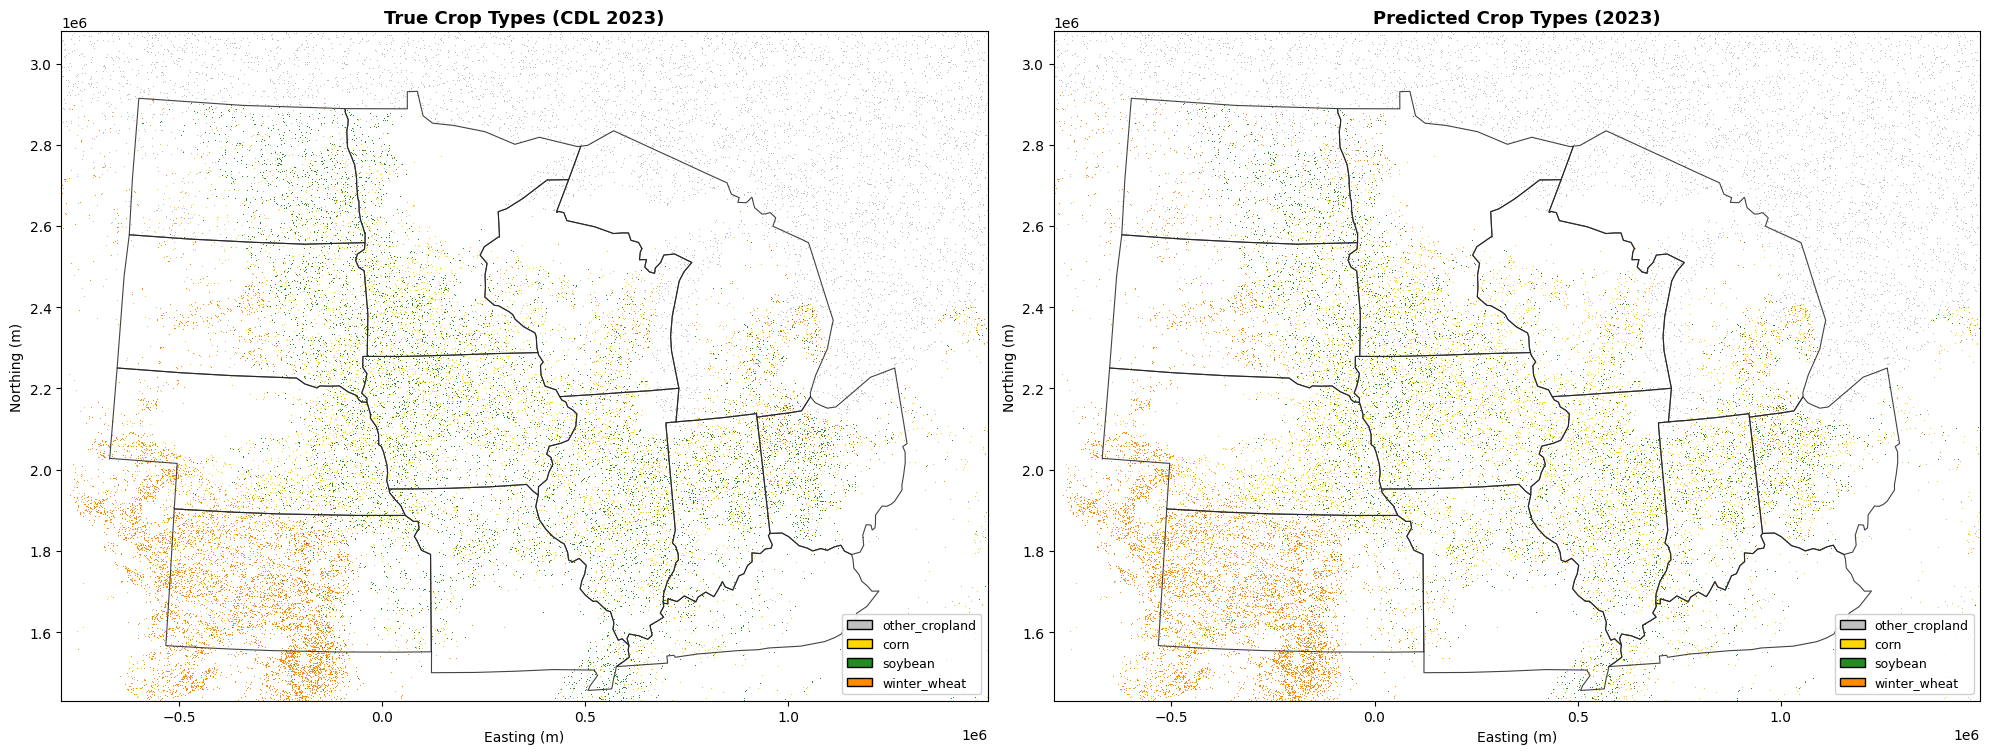

In [4]:
from src.viz.prediction_maps import plot_crop_type_map
from src.viz.rotation_maps import load_cornbelt_state_boundaries_5070

# Load state boundaries for overlay
states = load_cornbelt_state_boundaries_5070(REPO_ROOT)
if states is not None:
    print(f"Loaded {len(states)} state boundaries for overlay")
else:
    print("State boundaries not available — maps will render without overlays")

# Compute geo-referenced extent from the affine transform
t = meta["transform"]  # [a, b, c, d, e, f] — rasterio ordering
left = t[2]
top = t[5]
right = left + t[0] * WIDTH
bottom = top + t[4] * HEIGHT
geo_extent = (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_crop_type_map(
    true_raster, ax=axes[0],
    class_names=CLASS_NAMES, class_colors=CLASS_COLORS,
    title=f"True Crop Types (CDL {cfg['panel']['test_year']})",
    nodata=NODATA,
    extent=geo_extent,
    state_shapes=states,
)

plot_crop_type_map(
    pred_raster, ax=axes[1],
    class_names=CLASS_NAMES, class_colors=CLASS_COLORS,
    title=f"Predicted Crop Types ({cfg['panel']['test_year']})",
    nodata=NODATA,
    extent=geo_extent,
    state_shapes=states,
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_crop_maps_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Agreement / Disagreement Map

Agreement: 396,028 / 500,000 (79.21%)
Disagreement: 103,972 / 500,000 (20.79%)


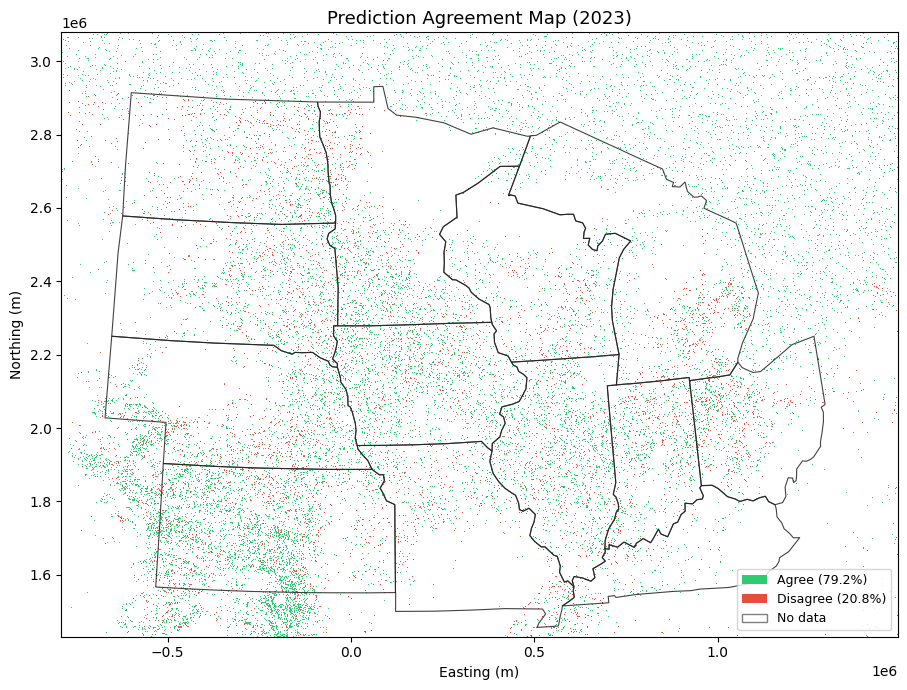

In [5]:
valid_mask = (true_raster != NODATA) & (pred_raster != NODATA)
agreement = np.full_like(true_raster, NODATA, dtype=np.int8)
agreement[valid_mask] = (true_raster[valid_mask] == pred_raster[valid_mask]).astype(np.int8)

n_agree = (agreement == 1).sum()
n_disagree = (agreement == 0).sum()
n_total = n_agree + n_disagree
print(f"Agreement: {n_agree:,} / {n_total:,} ({n_agree / max(n_total, 1):.2%})")
print(f"Disagreement: {n_disagree:,} / {n_total:,} ({n_disagree / max(n_total, 1):.2%})")

fig, ax = plt.subplots(figsize=(10, 7))

display_raster = np.full_like(agreement, np.nan, dtype=np.float32)
display_raster[agreement == 1] = 1.0
display_raster[agreement == 0] = 0.0

cmap_agree = ListedColormap(["#e74c3c", "#2ecc71"])
im = ax.imshow(display_raster, cmap=cmap_agree, vmin=0, vmax=1,
               interpolation="nearest", extent=geo_extent, aspect="equal")
ax.set_title(f"Prediction Agreement Map ({cfg['panel']['test_year']})", fontsize=13)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

if states is not None and not getattr(states, "empty", True):
    states.boundary.plot(ax=ax, color="#222222", linewidth=0.8, alpha=0.85)

legend_elements = [
    Patch(facecolor="#2ecc71", label=f"Agree ({n_agree / max(n_total, 1):.1%})"),
    Patch(facecolor="#e74c3c", label=f"Disagree ({n_disagree / max(n_total, 1):.1%})"),
    Patch(facecolor="white", edgecolor="gray", label="No data"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_agreement_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Optional: Export GeoTIFF

In [6]:
try:
    from src.viz.prediction_maps import save_geotiff
    from rasterio.transform import Affine

    transform = Affine(*meta["transform"][:6])
    crs = meta.get("crs", "EPSG:5070")

    save_geotiff(
        pred_raster.astype(np.int16),
        FIGURES_DIR / "task4_predicted_crop_map_2023.tif",
        transform=transform, crs=crs, nodata=-1,
    )
    print(f"Wrote {FIGURES_DIR / 'task4_predicted_crop_map_2023.tif'}")

except ImportError:
    print("rasterio not available; skipping GeoTIFF export.")
except Exception as e:
    print(f"GeoTIFF export failed: {e}")

rasterio not available; skipping GeoTIFF export.


## 6. Discussion

### 6.1 Model Performance Summary

The LightGBM crop-type classifier achieves strong overall accuracy on the temporal holdout test year (2023), with the ablation study (Notebook 02) demonstrating clear added value from both NDVI and SMAP features relative to a CDL-only baseline.

**Ablation value-add:**
- Adding **NDVI** features to CDL history captures within-season phenological differences — winter wheat greens up earlier in spring, corn reaches peak NDVI later than soybean, and the amplitude and integral of the NDVI curve differ by crop.
- Adding **SMAP** soil moisture features provides hydrological context — different crops respond differently to moisture conditions, and soil moisture at planting time helps distinguish spring-planted crops from winter wheat.
- The combined model (CDL+NDVI+SMAP) consistently outperforms single-source alternatives.

### 6.2 Rotation Regime Performance

As shown in Notebook 03, the model performs best on pixels with **regular** (corn–soy alternation) and **monoculture** (dominated by a single crop) rotation patterns, where CDL history features are highly informative.

**Irregular rotation** fields pose the greatest challenge: unpredictable crop sequences reduce the predictive power of historical lag codes and transition features. In these cases, NDVI and SMAP features become relatively more important, as they capture within-season biophysical characteristics that are independent of historical patterns. The SHAP analysis confirms that NDVI features (peak timing, greenup, amplitude) receive higher relative importance for pixels with irregular rotations.

### 6.3 Limitations

1. **Spatial resolution mismatch:** CDL is at 30 m, NDVI at 250 m, and SMAP at 9 km. Resampling all to the 250 m common grid means that CDL labels and features at field boundaries may be mixed-pixel. SMAP features are effectively constant over large areas, limiting their spatial discriminative power.

2. **Temporal coverage gap:** SMAP data begins in 2015, so training samples from 2013–2014 have missing SMAP features. LightGBM handles NaN natively, but these early years contribute less information about soil moisture.

3. **Class imbalance:** Corn and soybean dominate the Corn Belt; winter wheat and other cropland classes are significantly under-represented. While `is_unbalance=True` in LightGBM partially addresses this, minority-class F1 scores remain lower.

4. **Geographic generalisability:** The model is trained and evaluated solely on the 13-state Corn Belt. Performance may degrade in regions with different cropping systems (e.g., cotton in the South, rice in the Mississippi Delta) where the CDL crop-code vocabulary and NDVI phenology patterns differ.

5. **Temporal stationarity:** The model assumes crop rotation patterns and phenological signatures remain stable over time. Climate change, shifting agricultural practices, and policy changes (e.g., crop insurance incentives) may erode this assumption.

### 6.4 Future Work

- **Ensemble methods:** Combine LightGBM with other classifiers (XGBoost, CatBoost, random forest) via stacking or voting for more robust predictions.
- **Spatial cross-validation:** Replace random temporal holdout with spatially blocked CV to better estimate generalisation to unseen regions.
- **Full NDVI time series as features:** Rather than aggregating to 11 phenology statistics, explore using raw weekly NDVI profiles as input via temporal CNNs or transformer architectures.
- **External feature integration:** Incorporate soil properties (gSSURGO), terrain (elevation, slope from 3DEP), and weather (Daymet GDD, precipitation) to further improve classification, especially for minority classes and irregular-rotation pixels.
- **Multi-year prediction:** Extend the test evaluation to multiple held-out years to assess inter-annual robustness.